# Wprowadzenie do sieci neuronowych i uczenia maszynowego

## Lab: Własne moduły w PyTorch, regularyzacja i autoenkodery

---

**Autorzy materiałów:** Marek Wydmuch, Iwo Błądek, Jakub Bednarek<br>

---

## Uwaga

* **Aby wykonać polecenia należy najpierw przejść do trybu 'playground'. File -> Open in Playground Mode**
* Nowe funkcje Colab pozwalają na autouzupełnianie oraz czytanie dokumentacji.


## Cel ćwiczeń:

- zapoznanie się z tworzeniem własnych modułów w PyTorch
- wykorzystanie podstawowych mechanizmów regularyzacji: Dropout i Batch normalization

In [2]:
import numpy as np
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1+rocm6.4
CUDA available: True


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [3]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

train_data = datasets.MNIST(
    root="data", train=True, download=True, transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data", train=False, download=True, transform=ToTensor()
)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

## Własne moduły (warstwy sieci neuronowych) w PyTorch



Na poprzednich zajęciach używaliśmy gotowych modułów reprezentujących warstwy sieci neuronowych by stworzyć główny moduł naszego modułu.

W PyTorch nie ma żadnej hierarchii modułów (jak np. w TensorFlow czy Keras, gdzie API jest podzielone na modele i warstwy). Każdy moduł może używać innych modułów jako swoich komponentów.

Poniżej przykładowa implementacja modułu warstwy liniowej całkowicie od podstaw.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim


class CustomLayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CustomLayer, self).__init__()
        # Parametry (wagi) naszego modułu
        self.weights = nn.Parameter(torch.Tensor(input_dim, output_dim))
        # Inicjalizacja wag
        nn.init.xavier_normal_(self.weights)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return torch.mm(x, self.weights)


class CustomModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomModel, self).__init__()
        self.layers = nn.Sequential(
            CustomLayer(784, 512),
            nn.ReLU(),
            CustomLayer(512, 512),
            nn.ReLU(),
            CustomLayer(512, num_classes),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        return self.layers(x)

In [5]:
# Setup naszego modelu
model = CustomModel(num_classes=10).cuda()
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()


def accuracy(pred, target):
    return (pred.argmax(1) == target).type(torch.float).sum().item()


# Pętla treningowa i testowa
def train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=None,
    epochs=10,
    verbose=False,
):
    epochs_history = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_metric = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data = data.cuda()
            target = target.cuda()
            optimizer.zero_grad()
            pred = model(data)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

            if verbose and batch_idx % 100 == 0:
                print(f"Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}")
            train_loss += loss.item() * data.size(0)
            train_metric += metric(pred, target)
        if verbose:
            train_loss /= len(train_loader.dataset)
            train_metric /= len(train_loader.dataset)
            print(f"Train loss: {train_loss:.4f}")
            print(f"Train {metric.__name__}: {train_metric:.4f}")

        model.eval()
        test_metric = 0
        test_loss = 0
        for batch_idx, (data, target) in enumerate(test_loader):
            data = data.cuda()
            target = target.cuda()
            pred = model(data)
            loss = criterion(pred, target)
            test_loss += loss.item() * data.size(0)
            test_metric += metric(pred, target)
        if verbose:
            test_loss /= len(test_loader.dataset)
            test_metric /= len(test_loader.dataset)
            print(f"Test loss: {test_loss:.4f}")
            print(f"Test {metric.__name__}: {test_metric:.4f}")
            print("-------------------------------")

        epochs_history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                f"train_{metric.__name__}": train_metric,
                "test_loss": test_loss,
                f"test_{metric.__name__}": test_metric,
            }
        )
    return epochs_history


_ = train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=accuracy,
    epochs=10,
    verbose=True,
)

Epoch: 0, Batch: 0, Loss: 2.3002
Epoch: 0, Batch: 100, Loss: 1.5784
Epoch: 0, Batch: 100, Loss: 1.5784
Epoch: 0, Batch: 200, Loss: 1.5206
Epoch: 0, Batch: 200, Loss: 1.5206
Epoch: 0, Batch: 300, Loss: 1.5023
Epoch: 0, Batch: 300, Loss: 1.5023
Epoch: 0, Batch: 400, Loss: 1.4990
Epoch: 0, Batch: 400, Loss: 1.4990
Train loss: 1.5574
Train accuracy: 0.9119
Train loss: 1.5574
Train accuracy: 0.9119
Test loss: 1.5059
Test accuracy: 0.9568
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5089
Test loss: 1.5059
Test accuracy: 0.9568
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5089
Epoch: 1, Batch: 100, Loss: 1.5034
Epoch: 1, Batch: 100, Loss: 1.5034
Epoch: 1, Batch: 200, Loss: 1.5345
Epoch: 1, Batch: 200, Loss: 1.5345
Epoch: 1, Batch: 300, Loss: 1.4982
Epoch: 1, Batch: 300, Loss: 1.4982
Epoch: 1, Batch: 400, Loss: 1.4965
Epoch: 1, Batch: 400, Loss: 1.4965
Train loss: 1.5040
Train accuracy: 0.9592
Train loss: 1.5040
Train accuracy: 0.9592
Test loss: 1.4969
Test accura

### Zadanie 1

Stwórz prosty model
- warstwy konwolucyjnej (Conv2D): 32 filtry 3x3,
- konwolucyjnej: 64 filtry 3x3,
- warstwy MaxPooling (MaxPooling2D): 2x2
- warstwy ukrytej gęstej (Dense): 128 neuronów,
- warstwy wyjściowej.

Ważne:
- w każdej warstwie poza warstwą wyjściową funkcją aktywacji powinno być relu,
- funkcja aktywacji dla warstwy wyjściowej to softmax,
- między częścią konwolucyjną a gęstą trzeba spłaszczyć tensor przy pomocy warstwy `nn.Flatten`.

In [6]:
class SimpleModel(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
            nn.Softmax(dim=1),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.layers(x)


model = SimpleModel(num_classes=10).cuda()
optimizer = optim.Adam(model.parameters())
_ = train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=accuracy,
    epochs=10,
    verbose=True,
)

Epoch: 0, Batch: 0, Loss: 2.3034
Epoch: 0, Batch: 100, Loss: 1.6123
Epoch: 0, Batch: 100, Loss: 1.6123
Epoch: 0, Batch: 200, Loss: 1.5390
Epoch: 0, Batch: 200, Loss: 1.5390
Epoch: 0, Batch: 300, Loss: 1.4981
Epoch: 0, Batch: 300, Loss: 1.4981
Epoch: 0, Batch: 400, Loss: 1.4857
Epoch: 0, Batch: 400, Loss: 1.4857
Train loss: 1.5374
Train accuracy: 0.9290
Train loss: 1.5374
Train accuracy: 0.9290
Test loss: 1.4868
Test accuracy: 0.9759
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5005
Test loss: 1.4868
Test accuracy: 0.9759
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5005
Epoch: 1, Batch: 100, Loss: 1.4785
Epoch: 1, Batch: 100, Loss: 1.4785
Epoch: 1, Batch: 200, Loss: 1.4735
Epoch: 1, Batch: 200, Loss: 1.4735
Epoch: 1, Batch: 300, Loss: 1.4680
Epoch: 1, Batch: 300, Loss: 1.4680
Epoch: 1, Batch: 400, Loss: 1.4858
Epoch: 1, Batch: 400, Loss: 1.4858
Train loss: 1.4843
Train accuracy: 0.9778
Train loss: 1.4843
Train accuracy: 0.9778
Test loss: 1.4771
Test accura

## Zadanie 2

Na podstawie powyższego przykładu stwórz moduł bloku ResNet.
Zadbaj o to by rozmiary tensorów po warstwach konwolucyjnych się nie zmieniały.

![resnet](https://miro.medium.com/max/1000/1*6HDuqhUzP92iXhHoS0Wl3w.png)

Zmodyfikuj model z zadania 1, zamieniając warstwy konwolucyjne na dwa modele bloku ResNet.



In [7]:
# Zadanie 2 - Blok ResNet
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        # Skip connection - jeśli wymiary się różnią
        self.skip = nn.Identity()
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class ResNetModel(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetModel, self).__init__()
        self.layers = nn.Sequential(
            ResNetBlock(1, 32),
            ResNetBlock(32, 64),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        return self.layers(x)


model = ResNetModel(num_classes=10).cuda()
optimizer = optim.Adam(model.parameters())
_ = train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=accuracy,
    epochs=10,
    verbose=True,
)

Epoch: 0, Batch: 0, Loss: 2.3111
Epoch: 0, Batch: 100, Loss: 1.7783
Epoch: 0, Batch: 100, Loss: 1.7783
Epoch: 0, Batch: 200, Loss: 1.6332
Epoch: 0, Batch: 200, Loss: 1.6332
Epoch: 0, Batch: 300, Loss: 1.6094
Epoch: 0, Batch: 300, Loss: 1.6094
Epoch: 0, Batch: 400, Loss: 1.5809
Epoch: 0, Batch: 400, Loss: 1.5809
Train loss: 1.6940
Train accuracy: 0.7649
Train loss: 1.6940
Train accuracy: 0.7649
Test loss: 1.5824
Test accuracy: 0.8787
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5319
Test loss: 1.5824
Test accuracy: 0.8787
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5319
Epoch: 1, Batch: 100, Loss: 1.5504
Epoch: 1, Batch: 100, Loss: 1.5504
Epoch: 1, Batch: 200, Loss: 1.5627
Epoch: 1, Batch: 200, Loss: 1.5627
Epoch: 1, Batch: 300, Loss: 1.5704
Epoch: 1, Batch: 300, Loss: 1.5704
Epoch: 1, Batch: 400, Loss: 1.4767
Epoch: 1, Batch: 400, Loss: 1.4767
Train loss: 1.5587
Train accuracy: 0.9022
Train loss: 1.5587
Train accuracy: 0.9022
Test loss: 1.4808
Test accura

## Regularyzacja

### Zadanie 3

Rozszerz model stworzony w zadaniu 1 o dwie warstwy Dropout (nn.Dropout):
- jedna po warstwie MaxPooling (wartość współczynnika odrzucenia 0.25)
- druga po gęstej warstwie ukrytej (Dense), wartość współczynnika odrzucenia 0.5.
- dodaj opcję włączenia i wyłączenia dropoutu jako argument konstruktora modułu modelu.



In [8]:
# Zadanie 3 - Model z Dropout
class ModelWithDropout(nn.Module):
    def __init__(self, num_classes=10, use_dropout=True):
        super(ModelWithDropout, self).__init__()
        self.use_dropout = use_dropout

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        if self.use_dropout:
            x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout2(x)
        x = torch.softmax(self.fc2(x), dim=1)
        return x


model = ModelWithDropout(num_classes=10, use_dropout=True).cuda()
optimizer = optim.Adam(model.parameters())
_ = train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=accuracy,
    epochs=10,
    verbose=True,
)

Epoch: 0, Batch: 0, Loss: 2.3029
Epoch: 0, Batch: 100, Loss: 1.6380
Epoch: 0, Batch: 100, Loss: 1.6380
Epoch: 0, Batch: 200, Loss: 1.5344
Epoch: 0, Batch: 200, Loss: 1.5344
Epoch: 0, Batch: 300, Loss: 1.5251
Epoch: 0, Batch: 300, Loss: 1.5251
Epoch: 0, Batch: 400, Loss: 1.5064
Epoch: 0, Batch: 400, Loss: 1.5064
Train loss: 1.6047
Train accuracy: 0.8624
Train loss: 1.6047
Train accuracy: 0.8624
Test loss: 1.4965
Test accuracy: 0.9657
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5595
Test loss: 1.4965
Test accuracy: 0.9657
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5595
Epoch: 1, Batch: 100, Loss: 1.5015
Epoch: 1, Batch: 100, Loss: 1.5015
Epoch: 1, Batch: 200, Loss: 1.5233
Epoch: 1, Batch: 200, Loss: 1.5233
Epoch: 1, Batch: 300, Loss: 1.5192
Epoch: 1, Batch: 300, Loss: 1.5192
Epoch: 1, Batch: 400, Loss: 1.4875
Epoch: 1, Batch: 400, Loss: 1.4875
Train loss: 1.5104
Train accuracy: 0.9535
Train loss: 1.5104
Train accuracy: 0.9535
Test loss: 1.4840
Test accura

### Zadanie 4
Rozszerz model stworzony w poprzednich zadaniach o dwie warstwy Batch normalization (nn.BatchNorm2d) po warstwach konwolucyjnych. Dodaj opcję włączenia i wyłączenia dropoutu jako argument konstruktora modułu modelu.



In [9]:
# Zadanie 4 - Model z Dropout i BatchNorm
class ModelWithRegularization(nn.Module):
    def __init__(self, num_classes=10, use_dropout=True, use_batchnorm=True):
        super(ModelWithRegularization, self).__init__()
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool(x)
        if self.use_dropout:
            x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout2(x)
        x = torch.softmax(self.fc2(x), dim=1)
        return x


model = ModelWithRegularization(
    num_classes=10, use_dropout=True, use_batchnorm=True
).cuda()
optimizer = optim.Adam(model.parameters())
_ = train_and_test(
    train_loader,
    test_loader,
    model,
    optimizer,
    criterion,
    metric=accuracy,
    epochs=10,
    verbose=True,
)

Epoch: 0, Batch: 0, Loss: 2.3036
Epoch: 0, Batch: 100, Loss: 1.5800
Epoch: 0, Batch: 100, Loss: 1.5800
Epoch: 0, Batch: 200, Loss: 1.5140
Epoch: 0, Batch: 200, Loss: 1.5140
Epoch: 0, Batch: 300, Loss: 1.5222
Epoch: 0, Batch: 300, Loss: 1.5222
Epoch: 0, Batch: 400, Loss: 1.5200
Epoch: 0, Batch: 400, Loss: 1.5200
Train loss: 1.5654
Train accuracy: 0.8992
Train loss: 1.5654
Train accuracy: 0.8992
Test loss: 1.4866
Test accuracy: 0.9752
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5181
Test loss: 1.4866
Test accuracy: 0.9752
-------------------------------
Epoch: 1, Batch: 0, Loss: 1.5181
Epoch: 1, Batch: 100, Loss: 1.5110
Epoch: 1, Batch: 100, Loss: 1.5110
Epoch: 1, Batch: 200, Loss: 1.5372
Epoch: 1, Batch: 200, Loss: 1.5372
Epoch: 1, Batch: 300, Loss: 1.5247
Epoch: 1, Batch: 300, Loss: 1.5247
Epoch: 1, Batch: 400, Loss: 1.5183
Epoch: 1, Batch: 400, Loss: 1.5183
Train loss: 1.5048
Train accuracy: 0.9573
Train loss: 1.5048
Train accuracy: 0.9573
Test loss: 1.4833
Test accura

### Zadanie 5
Porównaj model bez oraz z różnych kombinacjami technik regularyzacji (z dropoutem ale bez batch norm., bez dropout ale z batch norm., z dropoutem i z batch norm.).
Stwórz cztery wykresy:
- błąd funkcji celu dla zbioru treningowego,
- błąd funkcji celu dla zbioru walidacyjnego,
- trafność klasyfikacji dla zbioru treningowego,
- trafność klasyfikacji dla zbioru walidacyjnego.


=== Bez regularyzacji ===

=== Tylko Dropout ===

=== Tylko Dropout ===

=== Tylko BatchNorm ===

=== Tylko BatchNorm ===

=== Dropout + BatchNorm ===

=== Dropout + BatchNorm ===


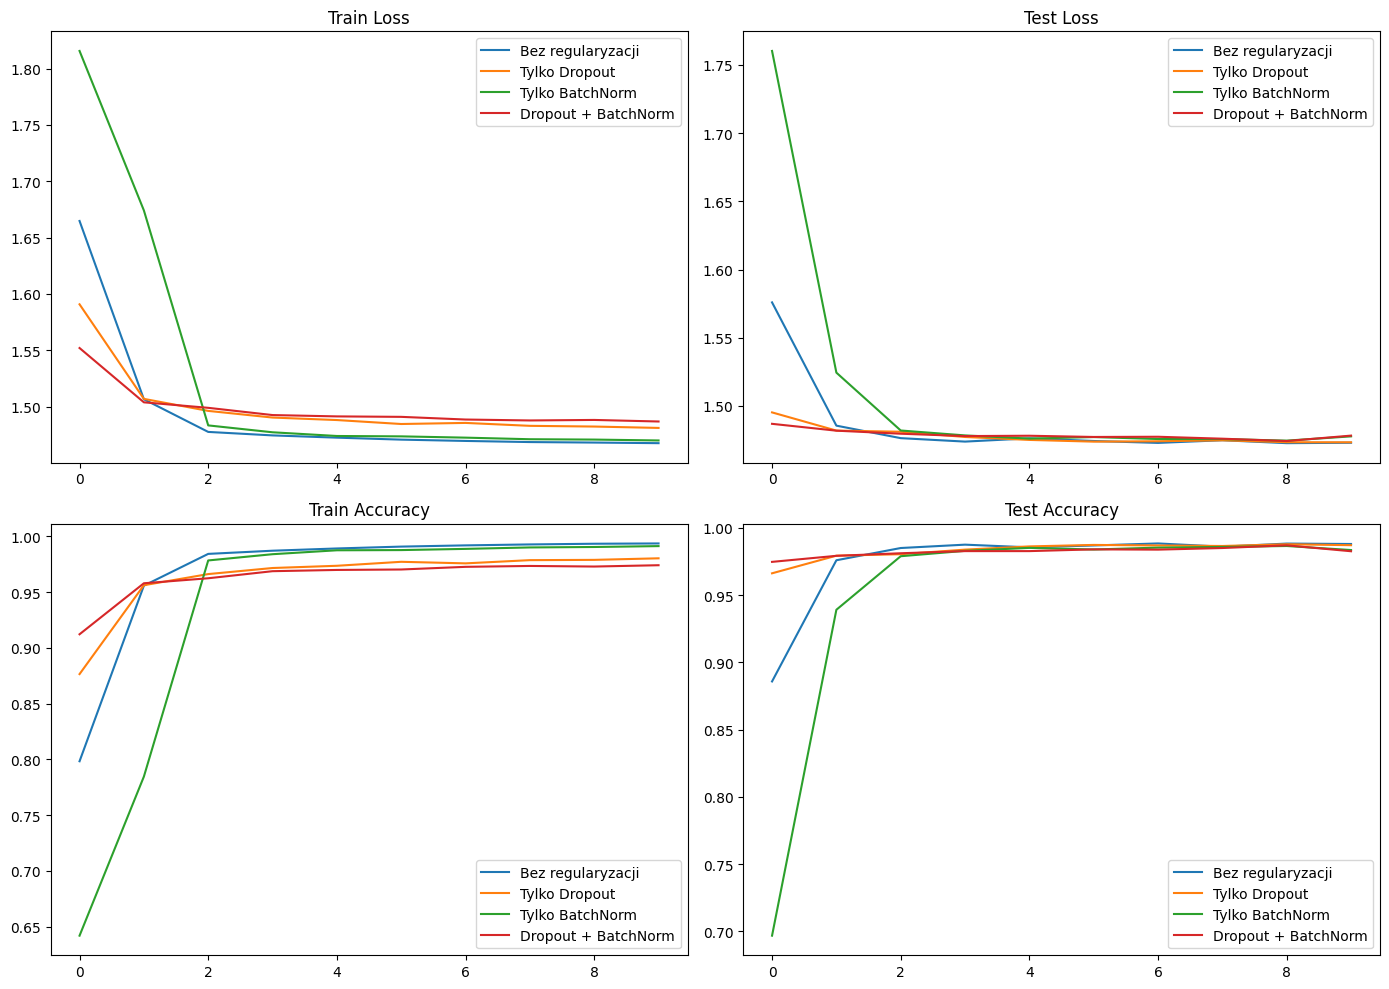

In [10]:
# Zadanie 5 - Porównanie regularyzacji
configs = [
    {"name": "Bez regularyzacji", "dropout": False, "batchnorm": False},
    {"name": "Tylko Dropout", "dropout": True, "batchnorm": False},
    {"name": "Tylko BatchNorm", "dropout": False, "batchnorm": True},
    {"name": "Dropout + BatchNorm", "dropout": True, "batchnorm": True},
]

all_histories = {}
for cfg in configs:
    print(f"\n=== {cfg['name']} ===")
    model = ModelWithRegularization(
        num_classes=10, use_dropout=cfg["dropout"], use_batchnorm=cfg["batchnorm"]
    ).cuda()
    optimizer = optim.Adam(model.parameters())
    history = train_and_test(
        train_loader,
        test_loader,
        model,
        optimizer,
        criterion,
        metric=accuracy,
        epochs=10,
        verbose=False,
    )
    all_histories[cfg["name"]] = history

# Wykresy
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for name, history in all_histories.items():
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] / len(train_loader.dataset) for h in history]
    test_loss = [h["test_loss"] / len(test_loader.dataset) for h in history]
    train_acc = [h["train_accuracy"] / len(train_loader.dataset) for h in history]
    test_acc = [h["test_accuracy"] / len(test_loader.dataset) for h in history]

    axes[0, 0].plot(epochs, train_loss, label=name)
    axes[0, 1].plot(epochs, test_loss, label=name)
    axes[1, 0].plot(epochs, train_acc, label=name)
    axes[1, 1].plot(epochs, test_acc, label=name)

axes[0, 0].set_title("Train Loss")
axes[0, 0].legend()
axes[0, 1].set_title("Test Loss")
axes[0, 1].legend()
axes[1, 0].set_title("Train Accuracy")
axes[1, 0].legend()
axes[1, 1].set_title("Test Accuracy")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

## Autoenkodery

Ideę autoenkodera prezentuje poniższy rysunek:
![label-autoencoder_schema](https://drive.google.com/uc?export=view&id=1Ai2ER1ppKfnHg5t_lCwO_fvvFNe59dgd)

Widzimy tutaj, że obrazek ze zbioru MNIST o rozmiarze 28 x 28 został skompresowany przez **enkoder** do tensora o rozmiarze 5 x 2. Tensor ten nosi nazwę **wektora zmiennych ukrytych** (ang. latent vector). Następnie **dekoder** przyjął ten wektor na wejście, i odtworzył oryginalny obrazek. Jest to przykład zadania **autoasocjacji**, gdzie celem uczenia sieci neuronowej jest możliwie wierne odtworzenie danych wejściowych. Zadanie to może się wydawać bez sensu w odosobnieniu (po co odtwarzać coś, co już mamy?), jednak to co nas najbardziej interesuje w autoenkoderze to wektor zmiennych ukrytych. Jako że skompresowaliśmy cały obrazek do 10 wartości, to by realistyczne odtworzenie z nich oryginalnego obrazka było możliwe, każda z tych wartości musi 1) zawierać o nim możliwie dużo informacji, 2) nieistotne detale oryginalnego obrazka muszą zostać pominięte. Wyciągnęliśmy więc z danych informacyjną "esencję", pozbyliśmy się redundatnych elementów opisu.

<br>

Najważniejszą cechą autoenkodera jest właśnie **uczenie się efektywnego kodowania danych**, co zazwyczaj wiąże się z redukcją wymiarowości (tzw. 'undercomplete autoencoders'), choć można też uczyć autoenkodery o kodowaniu zwiększającym wymiarowość (tzw. 'overcomplete autoencoders'). Skupimy się na autoenkoderach zmniejszających wymiarowość, bo ich uczenie jest znacznie prostsze. W przeciwieństwie do np. PCA kodowanie uzyskane przez taki autoenkoder może być nieliniowe, tak więc zmienne ukryte mają więcej elastyczności w reprezentacji danych. Selekcja atrybutów, której podstawy omawialiśmy wcześniej na przedmiocie, również redukuje wymiarowość, ale nie zmienia informacji w atrybutach. W ogólności techniki redukcji wymiarowości tworzą zupełnie nowe atrybuty ze starych (np. $Y_1 = 0.5X_1 - 0.25X_2^2 + \log_2 X_3$, gdzie $Y_1$ to nowy atrybut, a $X_i$ to oryginalne atrybuty). Wiele zastosowań autoenkoderów buduje właśnie na tej zdolności, a także na tym, że dzięki procesowi uczenia sieci tworzymy metodę redukcji wymiarowości zoptymalizowaną do konkretnego problemu.

<br>

Autoenkodery mają wiele potencjalnych zastosowań, przykładowo:
* Redukcja wymiarowości - uczymy autoenkoder w trybie autoasocjacji, i naszym celem jest zmniejszenie wymiarowości danych, czyli zastąpienie oryginalnego obiektu jego wektorem zmiennych ukrytych. Można użyć jako alternatywy dla selekcji atrybutów i dedykowanych metod redukcji wymiarowości (PCA, LDA, etc.).
* Grupowanie - uczymy autoenkoder w trybie autoasocjacji, wykorzystujemy wektory zmiennych ukrytych uzyskane dla danych uczących jako wejście do algorytmu grupowania (np. k-means).
* Wyszukiwanie informacji - uczymy autoenkoder w trybie autoasocjacji, wykorzystujemy wektor zmiennych ukrytych jako hasz obiektu. Jeżeli chcemy znaleźć w bazie danych obiekty podobne do zadanego obiektu $X$, to generujemy wektor zmiennych ukrytych (hasz) $X$ przy użyciu enkodera i szukamy obiektów w zbiorze o najbardziej zbliżonych haszach. Technika ta nazywana jest haszowaniem semantycznym.
* Wykrywanie anomalii - uczymy autoenkoder w trybie autoasocjacji wyłącznie na przypadkach "normalnych". Liczymy na to, że jak kiedykolwiek autoenkoder dostanie do przetworzenia przypadek odstający/anomalię, to nie da rady jej dobrze zrekonstruować i błąd będzie wysoki (właśnie przez to, że nie miał szansy się na nich nauczyć).
* Generowanie danych - uczymy autoenkoder w trybie autoasocjacji, a następnie jak chcemy uzyskać różne warianty danego obrazu/obiektu, to modyfikujemy jego wygenerowany przez enkoder wektor zmiennych ukrytych, i dajemy go do przetworzenia dekoderowi. Możemy też po prostu losowo próbkować przestrzeń wektorów ukrytych i obserwować wyniki po przetworzeniu przez dekoder. Przy odrobinie szczęścia jakaś zmienna ukryta może np. odpowiadać za wyraz twarzy człowieka, i zmieniając wartości tej zmiennej możemy zmieniać wyłącznie wyraz twarzy człowieka na zdjęciu. Do tego zadania zazwyczaj wykorzystywany jest zmodyfikowany wariant autoenkodera: autoenkoder wariacyjny.
* Odszumianie - uczymy autoenkoder w trybie heteroasocjacji: *zaszumiony obraz* -> *oryginalny obraz*. Liczymy na to, że enkoder i dekoder nauczą się poprawnie rozpoznawać szum jako element redundantny, nieniosący żadnej informacji.<br>
![label-autoencoder_denoising](https://drive.google.com/uc?export=view&id=1a1fP7CWjzKSwo0txUBUMwaxTrpt6LzyH)



### Zadanie 6

Zaimplementuj autoenkoder o następującej architekturze:
* Enkoder: Dense(100) -> Dense(50) -> Dense(10) (wektor zmiennych ukrytych).
* Dekoder: Dense(50) -> Dense(100) -> Dense(784) (wyjściowy zrekonstruowany obrazek)

gdzie Dense(n) oznacza warstwę w pełni połączoną z *n* neuronami i funkcją aktywacji ReLU. Jako miarę błędu przyjmij MSE.

In [11]:
import torch
import torch.nn as nn
import torch.nn.init as init


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 784),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(-1, 784)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(-1, 1, 28, 28)
        return decoded


def train_and_test_ae(
    train_loader, test_loader, model, optimizer, criterion, epochs=10, verbose=False
):
    epochs_history = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            pred = model(data)
            loss = criterion(
                pred, data
            )  # autoasocjacja: porównujemy z danymi wejściowymi
            loss.backward()
            optimizer.step()
            if verbose and batch_idx % 100 == 0:
                print(f"Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}")
            train_loss += loss.item() * data.size(0)
        train_loss /= len(train_loader.dataset)
        if verbose:
            print(f"Train loss: {train_loss:.4f}")

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, target in test_loader:
                pred = model(data)
                loss = criterion(pred, data)
                test_loss += loss.item() * data.size(0)
        test_loss /= len(test_loader.dataset)
        if verbose:
            print(f"Test loss: {test_loss:.4f}")
            print("-------------------------------")
        epochs_history.append(
            {"epoch": epoch, "train_loss": train_loss, "test_loss": test_loss}
        )
    return epochs_history


model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.MSELoss()
_ = train_and_test_ae(
    train_loader, test_loader, model, optimizer, criterion, epochs=10, verbose=True
)

Epoch: 0, Batch: 0, Loss: 0.6977
Epoch: 0, Batch: 100, Loss: 0.0638
Epoch: 0, Batch: 100, Loss: 0.0638
Epoch: 0, Batch: 200, Loss: 0.0656
Epoch: 0, Batch: 200, Loss: 0.0656
Epoch: 0, Batch: 300, Loss: 0.0609
Epoch: 0, Batch: 300, Loss: 0.0609
Epoch: 0, Batch: 400, Loss: 0.0601
Epoch: 0, Batch: 400, Loss: 0.0601
Train loss: 0.0683
Train loss: 0.0683
Test loss: 0.0608
-------------------------------
Epoch: 1, Batch: 0, Loss: 0.0643
Test loss: 0.0608
-------------------------------
Epoch: 1, Batch: 0, Loss: 0.0643
Epoch: 1, Batch: 100, Loss: 0.0589
Epoch: 1, Batch: 100, Loss: 0.0589
Epoch: 1, Batch: 200, Loss: 0.0601
Epoch: 1, Batch: 200, Loss: 0.0601
Epoch: 1, Batch: 300, Loss: 0.0604
Epoch: 1, Batch: 300, Loss: 0.0604
Epoch: 1, Batch: 400, Loss: 0.0582
Epoch: 1, Batch: 400, Loss: 0.0582
Train loss: 0.0596
Train loss: 0.0596
Test loss: 0.0587
-------------------------------
Epoch: 2, Batch: 0, Loss: 0.0576
Test loss: 0.0587
-------------------------------
Epoch: 2, Batch: 0, Loss: 0.0576

### Zadanie 7

Użyj zaimplementowanego w poprzednim zadaniu autoenkodera by zaobserwować jak zmienia się odtwarzany obraz gdy zmienia się tylko jeden element wektora zmiennych ukrytych. Zadanie wykonywane jest w następujących krokach:
1. Użyj nauczonego enkodera z poprzedniego zadania na przypadku uczącym wybranej cyfry (dowolnej) by uzyskać wektor zmiennych ukrytych.
2. Wybierz konkretną zmienną ukrytą w tym wektorze, np. tę o indeksie 0.
3. W pętli podstawiaj różne wartości do tej zmiennej wektora z pewnym krokiem, i obserwuj obrazki generowane przez dekoder.

Original image


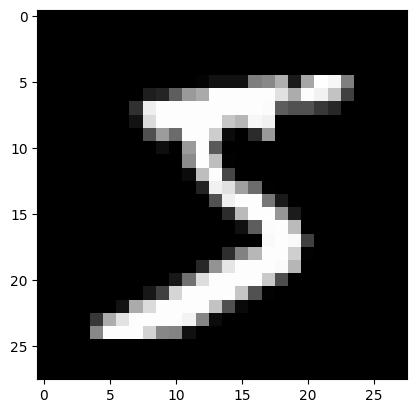

Reconstructed image


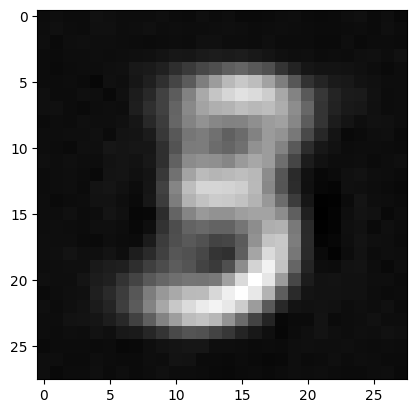

latent_vector: tensor([[0.0000, 0.2201, 0.0000, 0.0000, 0.6288, 0.0000, 0.0000, 0.0000, 1.5070,
         0.0000]])


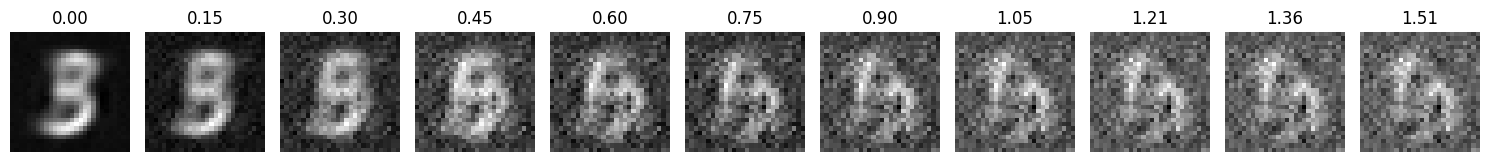

In [12]:
# Zadanie 7 - Manipulacja wektorem zmiennych ukrytych
example = train_data[0][0]
print("Original image")
plt.imshow(example.reshape((28, 28)), cmap="gray")
plt.show()

model.eval()
with torch.no_grad():
    latent_vector = model.encoder(example.view(-1, 784))
    output = model.decoder(latent_vector)

print("Reconstructed image")
plt.imshow(output.numpy().reshape(28, 28), cmap="gray")
plt.show()

print(f"latent_vector: {latent_vector}")

latent_idx = 0  # indeks zmiennej ukrytej do modyfikacji
fig, axes = plt.subplots(1, 11, figsize=(15, 2))

for i, e in enumerate(
    torch.linspace(torch.min(latent_vector), torch.max(latent_vector), 11)
):
    modified_latent = latent_vector.clone()
    modified_latent[0, latent_idx] = e
    with torch.no_grad():
        generated = model.decoder(modified_latent)
    axes[i].imshow(generated.numpy().reshape(28, 28), cmap="gray")
    axes[i].set_title(f"{e:.2f}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Zadanie 8

Wykorzystaj kod z poprzednich zadań by nauczyć autoenkoder odszumiania. Parę uwag:
* Musisz zmodyfikować zbiór uczący poprzez dodanie sztucznego szumu. Można to zrobić albo poprzez zmianę wartości kilku losowych pikseli w każdym obrazku, albo dodanie macierzy z małymi losowo generowanymi liczbami do obrazka (do każdego obrazka innej!). Oczekiwaną odpowiedzą podczas uczenia będzie oryginalny obrazek bez szumu.
* Architektura enkodera i dekodera może pozostać bez zmian, ale będziesz musiał ją nauczyć na nowym zbiorze danych, tak więc by nie psuć wyników z zadania nr 1 sugeruję przeklejenie odpowiedniego kodu tutaj.
* Zademonstruj działanie odszumiania poprzez pokazanie przypadku z szumem, a następnie zrekonstruowanego obrazka bez szumu po przetworzeniu przez autoenkoder.

Epoch 0, Loss: 0.0546
Epoch 1, Loss: 0.0418
Epoch 1, Loss: 0.0418
Epoch 2, Loss: 0.0387
Epoch 2, Loss: 0.0387
Epoch 3, Loss: 0.0359
Epoch 3, Loss: 0.0359
Epoch 4, Loss: 0.0348
Epoch 4, Loss: 0.0348
Epoch 5, Loss: 0.0341
Epoch 5, Loss: 0.0341
Epoch 6, Loss: 0.0336
Epoch 6, Loss: 0.0336
Epoch 7, Loss: 0.0331
Epoch 7, Loss: 0.0331
Epoch 8, Loss: 0.0327
Epoch 8, Loss: 0.0327
Epoch 9, Loss: 0.0324
Epoch 9, Loss: 0.0324


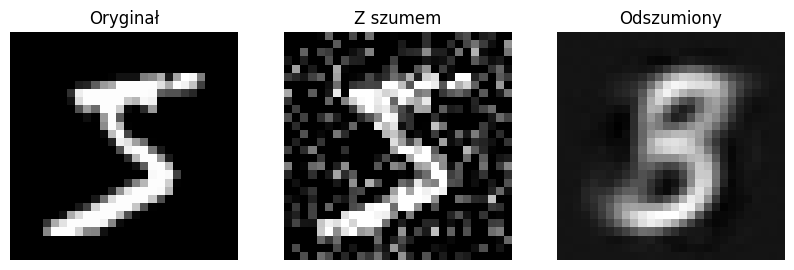

In [13]:
# Zadanie 8 - Autoenkoder odszumiający
noise_factor = 0.3


class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 784),
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.decoder(self.encoder(x)).view(-1, 1, 28, 28)


def train_denoising(
    train_loader, test_loader, model, optimizer, criterion, noise_factor, epochs=10
):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, _ in train_loader:
            noisy_data = data + noise_factor * torch.randn_like(data)
            noisy_data = torch.clamp(noisy_data, 0.0, 1.0)
            optimizer.zero_grad()
            output = model(noisy_data)
            loss = criterion(output, data)  # cel: oryginalne dane bez szumu
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.size(0)
        print(f"Epoch {epoch}, Loss: {train_loss / len(train_loader.dataset):.4f}")


denoising_model = DenoisingAutoencoder()
optimizer = torch.optim.Adam(denoising_model.parameters())
criterion = nn.MSELoss()
train_denoising(
    train_loader,
    test_loader,
    denoising_model,
    optimizer,
    criterion,
    noise_factor,
    epochs=10,
)

# Demonstracja odszumiania
denoising_model.eval()
example = train_data[0][0]
noisy_example = example + noise_factor * torch.randn_like(example)
noisy_example = torch.clamp(noisy_example, 0.0, 1.0)

with torch.no_grad():
    denoised = denoising_model(noisy_example.unsqueeze(0))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(example.squeeze(), cmap="gray")
axes[0].set_title("Oryginał")
axes[1].imshow(noisy_example.squeeze(), cmap="gray")
axes[1].set_title("Z szumem")
axes[2].imshow(denoised.squeeze(), cmap="gray")
axes[2].set_title("Odszumiony")
for ax in axes:
    ax.axis("off")
plt.show()